## Is there a relationship between demographic and personality?

As I have grown and encountered more and more people, I've noticed how my peers from different parts of the world approach social interaction and problem-solving in distinct ways. Furthermroe, cultural stereotypes (as my French grandmother would joke about the Germans being to rigid for her) are embedded into our language and cultural references. 

Thus, are these regional personality distinctions supported by data, or are they rooted in blind assumption? 

Furthermore, I notice that as I have entered college and have grown into a young adult, my personality has changed in similar timelines to my peers as we've entered a stage of life togehter.

Together these observations have led me to wonder whether key demographic similarities result in trends/predicitons in personality.

#### Setting up datasets

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the path to our data folder
data_path = './data/'

# Loading the datasets
class_df = pd.read_csv(f'{data_path}class_big5_data.csv')
openpsych_df = pd.read_csv(f'{data_path}openpsych_data.csv', sep='\t')
continent_df = pd.read_csv(f'{data_path}country-and-continent-codes-list-csv.csv')

### Distribution of Personality Traits on a Global Scale


We are going to attempt to determine whether the distribution of the big five personality traits of extraversion, agreeableness, conscientiousness, and neuroticism is similar across the contidnents. The way this measurement works is that different people have different levels of each. We are attempting to find the average of people's outcomes by continent, and then comparing this average agains the average of other continents. 

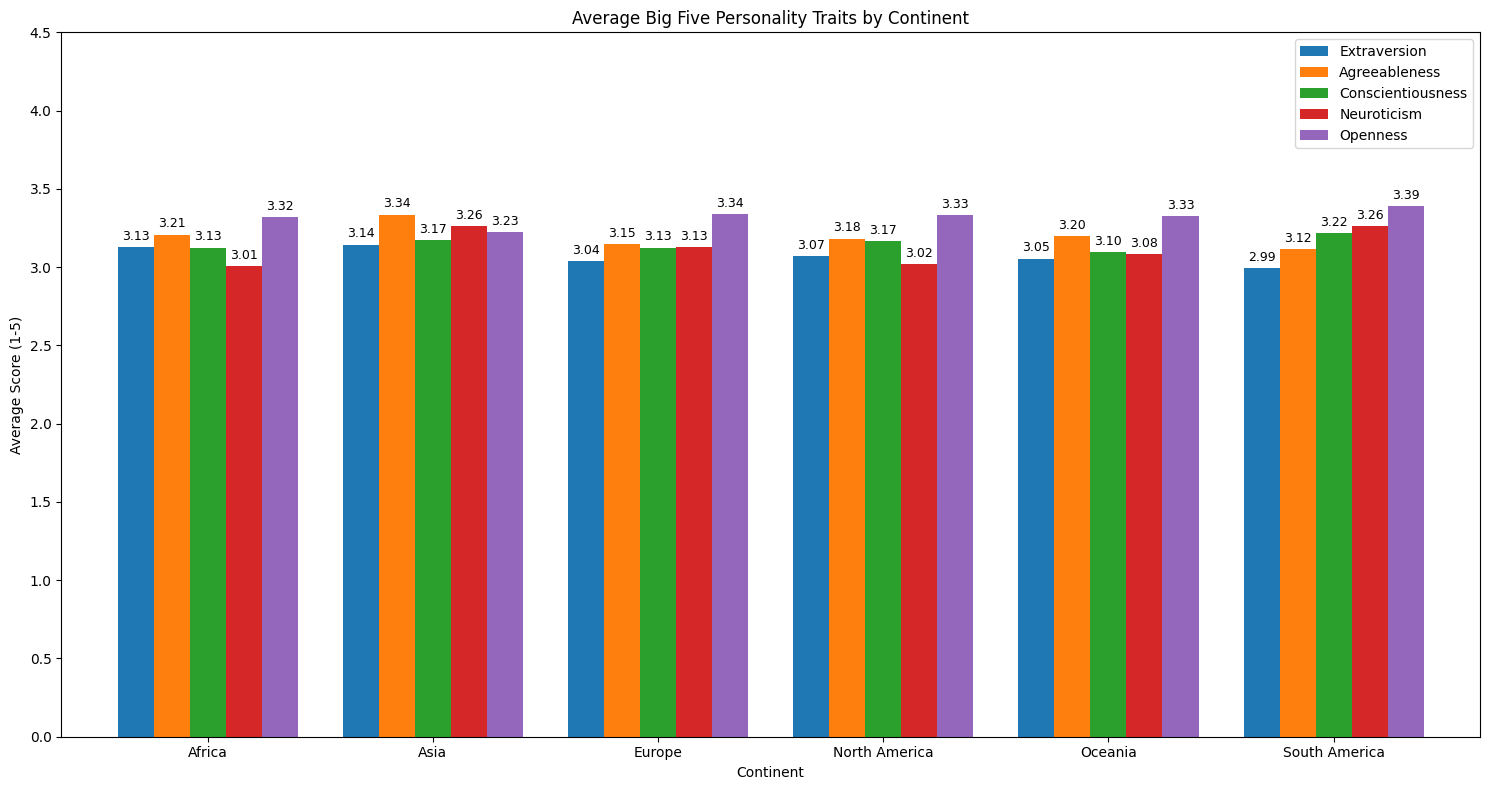

In [17]:
# Aggregate by continent to find the mean trait scores
continent_profile = merged_df.groupby('Continent_Name')[list(traits.keys())].mean()

# Visualization with Value Labels
ax = continent_profile.plot(kind='bar', figsize=(15, 8), width=0.8)

# Adding the values atop each bar
for container in ax.containers:
    # label_type='edge' puts the text on top of the bars
    # padding=3 adds a small gap between the bar and the text
    # fmt='%.2f' rounds the number to two decimal places
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.title('Average Big Five Personality Traits by Continent')
plt.ylabel('Average Score (1-5)')
plt.xlabel('Continent')
plt.xticks(rotation=0) # Keeps continent names horizontal for better readability
plt.legend(bbox_to_anchor=(1.0, 1.0)) # Moves legend outside to prevent overlapping bars
plt.ylim(0, 4.5) # Adds extra space at the top for labels
plt.tight_layout()
plt.show()

Across all continents, the average scores for traits tend to stay within a narrow range of around 0.15 between the smallest value and the largest value.  This suggests that regardless of geography, the aggregate human is quite similar across continents. The greatest variance is that of Neuroticism. In terms of Extraversion, one of the personality types we are most familiar with, South America and Europe show slightly higher averages compared to other regions. This aligns with cultural stereotypes, though further research will have to be done to understand their relationship. 

### Comparison to Our Classroom

Now that we have the global figures to compare to, let us compare our class averages to determine which continent we are the most similar to. Let us see whether our class, located in Phialdelphia, comprised of largely individuals from North America, is similar to the content North America. 

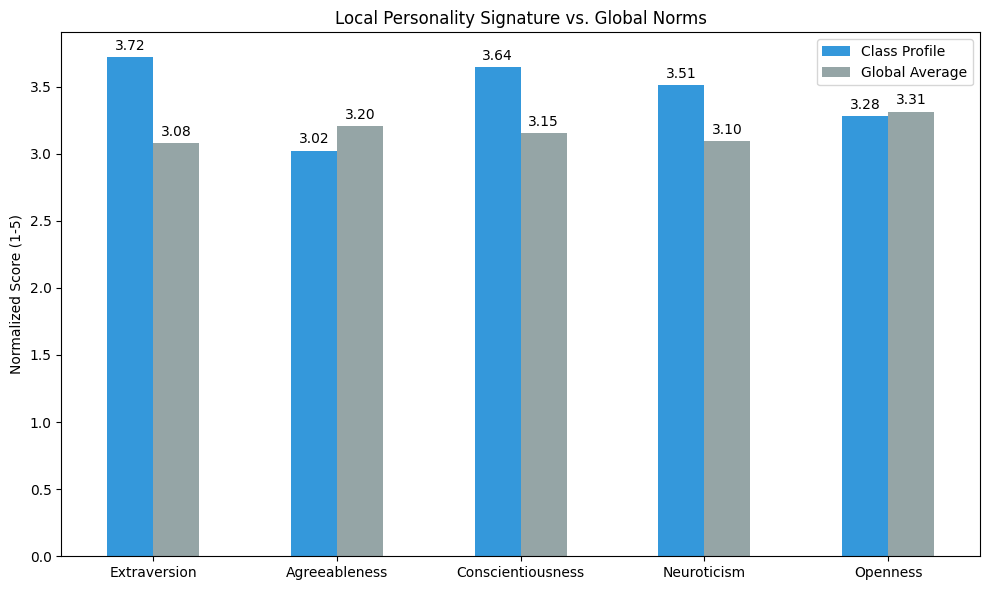

In [19]:
class_avg = class_df[['I', 'II', 'III', 'IV', 'V']].mean()
class_scaled = (class_avg / 25) + 1
class_scaled.index = list(traits.keys())

# Getting global average for comparison
global_avg = openpsych_df[list(traits.keys())].mean()
comparison_df = pd.DataFrame({'Class Profile': class_scaled, 'Global Average': global_avg})

# Plotting local vs global comparison
ax2 = comparison_df.plot(kind='bar', figsize=(10, 6), color=['#3498db', '#95a5a6'])
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.title('Local Personality Signature vs. Global Norms')
plt.ylabel('Normalized Score (1-5)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In terms of extraversion, our classroom scored much higher compared to the global average. This can be attributed to our class being comprised largely of individuals who are younger and are thus more social due to the tight knit culture ouf college. The agreeableness trait shows strong consistency. 

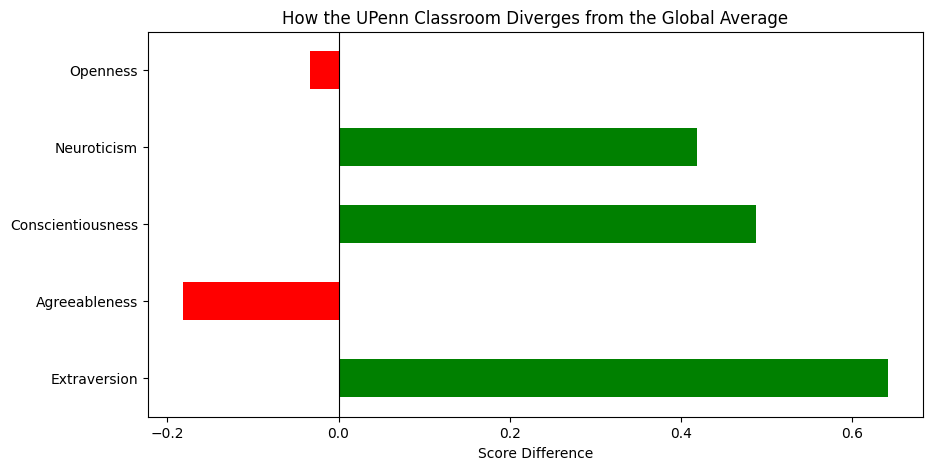

In [26]:
# Create a divergence plot
divergence = (class_scaled - global_avg).dropna()

plt.figure(figsize=(10, 5))
colors = ['red' if x < 0 else 'green' for x in divergence]
divergence.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('How the UPenn Classroom Diverges from the Global Average')
plt.xlabel('Score Difference')
plt.show()

This is another visualization on how our classroom diverged from the average global data, where the graphs provide a lot clearer of a visualization on how much our class diverged from the global average on key personality traits. 

### How does age intersect with personality and geography?

One of the key reasons why I hypothesize that the classroom showed higher signs of extraversion is due to our younger age and thus assumed extraversion due to more exposure to parties, informal hangouts, meeting new people, etc. However, does the data show that this is in fact a fair assumption? Furthermore, we will explore whether the "Maturity Principle" holds true, where people become more agreeable and conscientious as they grow older. We will see whether this is an assumption that holds true around the world.

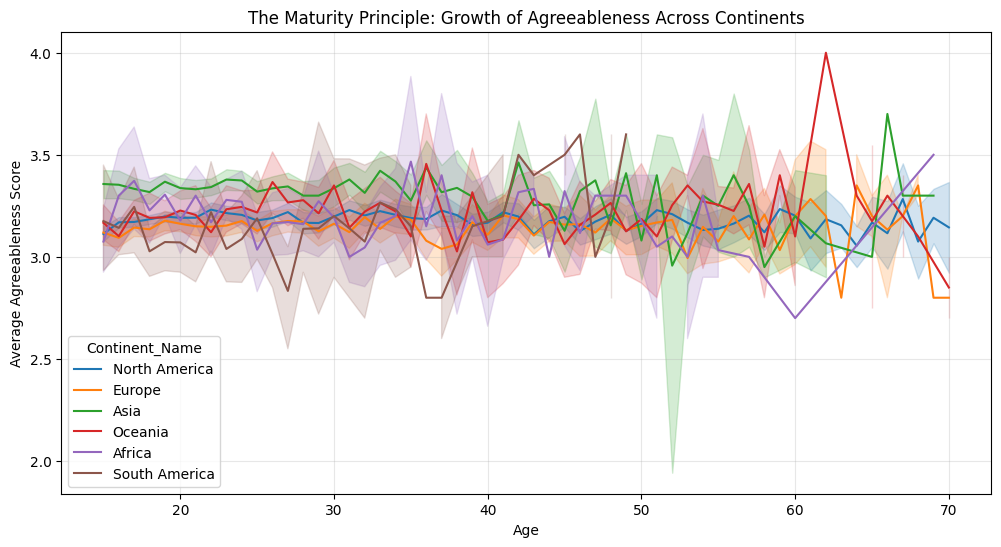

In [40]:
merged_df = openpsych_df.merge(continent_df, left_on='country', right_on='Two_Letter_Country_Code', how='left')
clean_age = merged_df[(merged_df['age'] >= 15) & (merged_df['age'] <= 70)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=clean_age, x='age', y='Agreeableness', hue='Continent_Name')
plt.title('The Maturity Principle: Growth of Agreeableness Across Continents')
plt.xlabel('Age')
plt.ylabel('Average Agreeableness Score')
plt.grid(alpha=0.3)
plt.show()    

This graph explores how the average agreeableness score evolves with time across the major continents. It is particularly interesting to note that among all the continents/regions, South Africa for the first 50 years has the most differeng trends, where it dips in the late 30s in agreeableness instead of spike up like the other continents. One of the most significant spies is the one in the early 60s for Oceana. Furthermore, after the 60s, the lines in agreeableness tend to be a bit more scattered in direction across the regions. I was wondering whether the count becomes more varied as the lifespan age across different regions differes–thus affecting the sample size and subsequently, affecting the average. 

### Gender & Geography

One highly debated topic is whether gender differences in personality are universal or culturally specific. In particular, we will explore the Gender Geographhy Paradox, the paradox that suggests that in societies with more gender equality and higher standards of living, the personality gaps between men and women actually increase rather than disappear. We will test this relationship by testing the difference for Neuroticism and Agreeableness across different continents.

/tmp/ipykernel_1760806/856056159.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_gap.index, y=gender_gap['Gap'], palette="coolwarm")


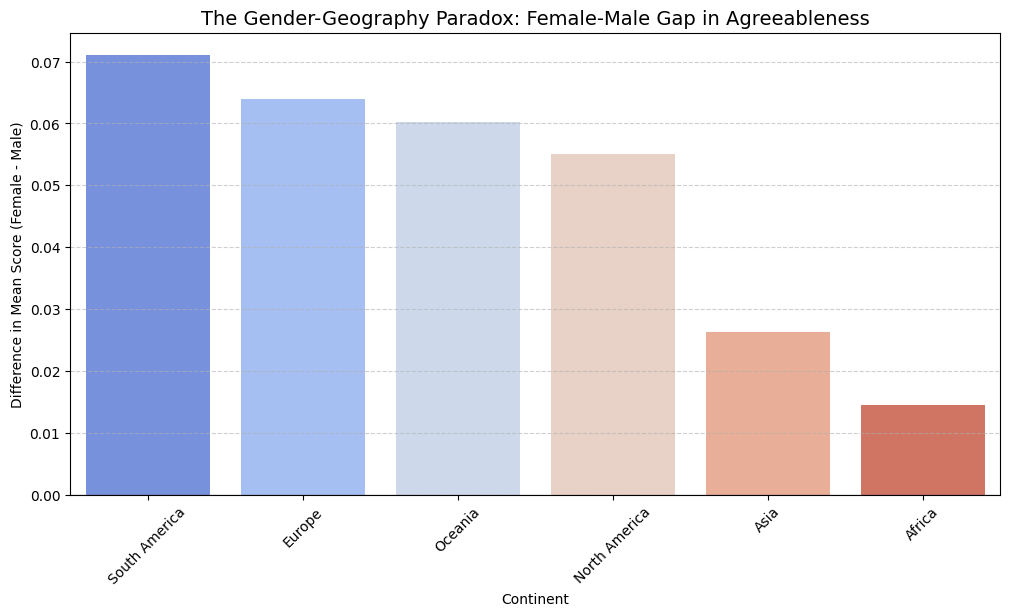

In [44]:
# 1. Filtering for valid gender data (1=Male, 2=Female)
gender_df = merged_df[merged_df['gender'].isin([1, 2])].copy()
gender_df['Gender_Label'] = gender_df['gender'].map({1: 'Male', 2: 'Female'})

# 2. Calculating the Gender Gap per Continent
gender_gap = gender_df.groupby(['Continent_Name', 'Gender_Label'])['Agreeableness'].mean().unstack()
gender_gap['Gap'] = gender_gap['Female'] - gender_gap['Male']
gender_gap = gender_gap.sort_values('Gap', ascending=False)

# 3. Visualizing the Paradox
plt.figure(figsize=(12, 6))
sns.barplot(x=gender_gap.index, y=gender_gap['Gap'], palette="coolwarm")

plt.axhline(0, color='black', linewidth=0.8)
plt.title('The Gender-Geography Paradox: Female-Male Gap in Agreeableness', fontsize=14)
plt.ylabel('Difference in Mean Score (Female - Male)')
plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

From this bar plot, we can observe that South America and Europe had the greatest difference between men and women, with Africa having the closest scores. This result doesn't support the paradox, though I would be interested to explore further demographic data such as income, family size, average number of women that are employed, etc. to learn more about what were the effects that led to the outcome of this graph. 

### Variation within continents

While we have done lots of exploration across different demographic factors, I would like to learn more about which continenets had the most varied personality scores. Would continents with a more diverse demographic yield more varied scores? Or is it in continents that have countries that emphasize self-expression and freedom of thought?

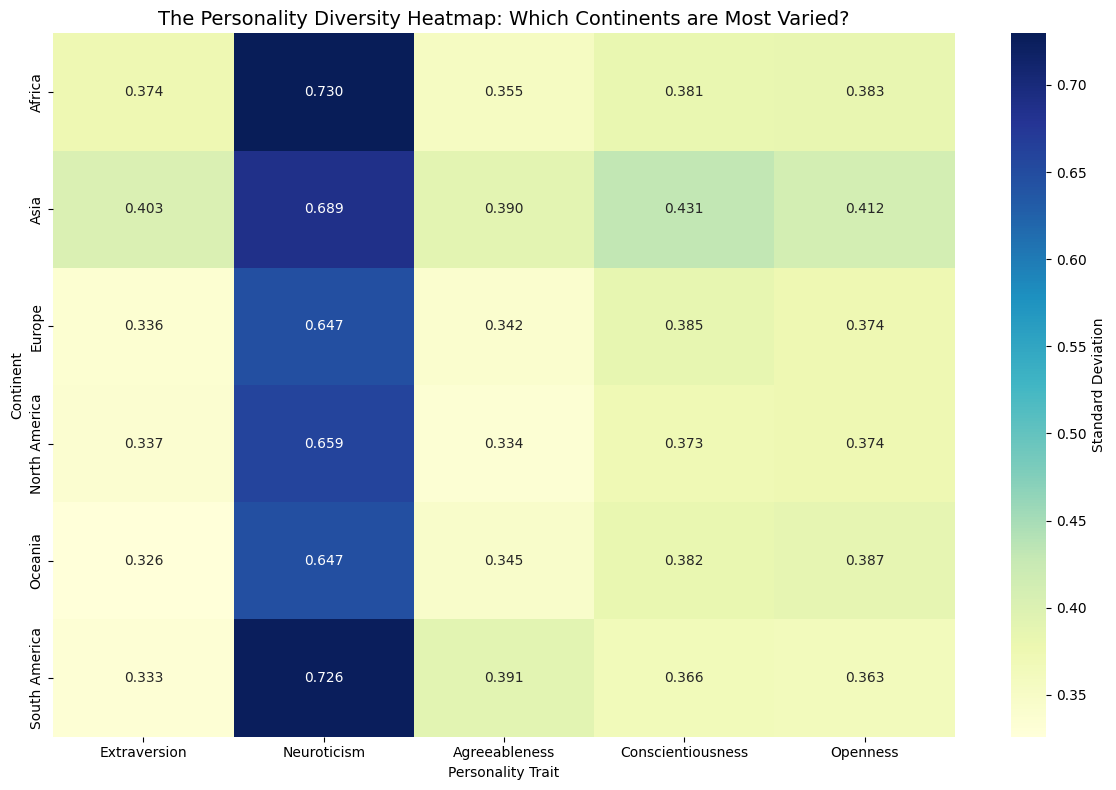

In [46]:

# 1. Calculating Standard Deviation for the Big Five traits by Continent
traits_list = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
diversity_df = merged_df.groupby('Continent_Name')[traits_list].std()

# 2. Visualizing Personality Diversity
plt.figure(figsize=(12, 8))
sns.heatmap(diversity_df, annot=True, cmap='YlGnBu', fmt='.3f', cbar_kws={'label': 'Standard Deviation'})

plt.title('The Personality Diversity Heatmap: Which Continents are Most Varied?', fontsize=14)
plt.xlabel('Personality Trait')
plt.ylabel('Continent')
plt.tight_layout()
plt.show()

Neuroticism showed the most varied numbers across all continenets. Extraversion was the most consistent across all continents.  I believe that sample size has a huge effect on the way these results pan out, as Asia is easily the largest continent spanning the most countries. Thus, there are more diverse peoples present in Asia compared to other continents, yielding the most varied result.  This is further supported by Africa having the second largest population, and thus also having the second most varied result in personality. 

### Conclusion 

In conclusion, there were many different relationships in the data with regards to age, gender, sample size, and more. I believe that further exploration can be done with more information that spanned across the data sets. Additionally, I would be interested in exploring more into the relationship between self-reported data on personality type versus the outcomes that would occur when someone else is defining your personality. Would these differences also change across countries? Furthermore, I would love to learn mroe about whether the surrounding demographics of where a person lives has an effect on their personality. Are people from more diverse areas more likely to have a certain personality trait? Additionally, does that predictor change with the population density of a location? I have lots of questions that I believe can be answered with additional data, and furhter data cleaning. 